In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(1081)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(283726, 31)

In [14]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [15]:
fraud_percentage = (df["Class"].value_counts()[1] / len(df)) * 100
fraud_percentage

np.float64(0.1667101358352777)

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [17]:
print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

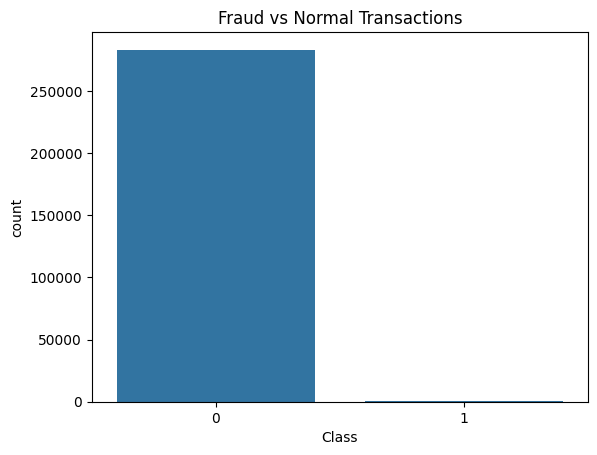

In [20]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

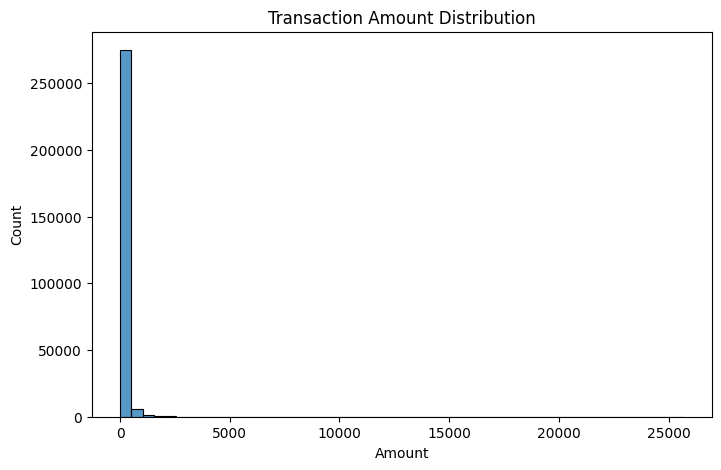

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

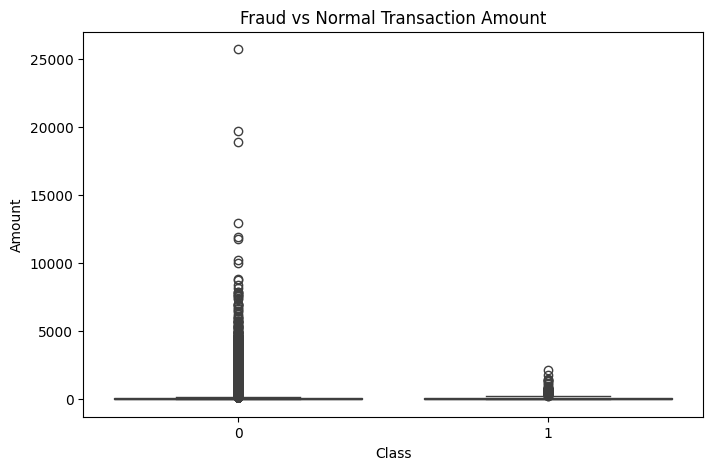

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraud vs Normal Transaction Amount")
plt.show()

In [23]:
corr_matrix = df.corr()

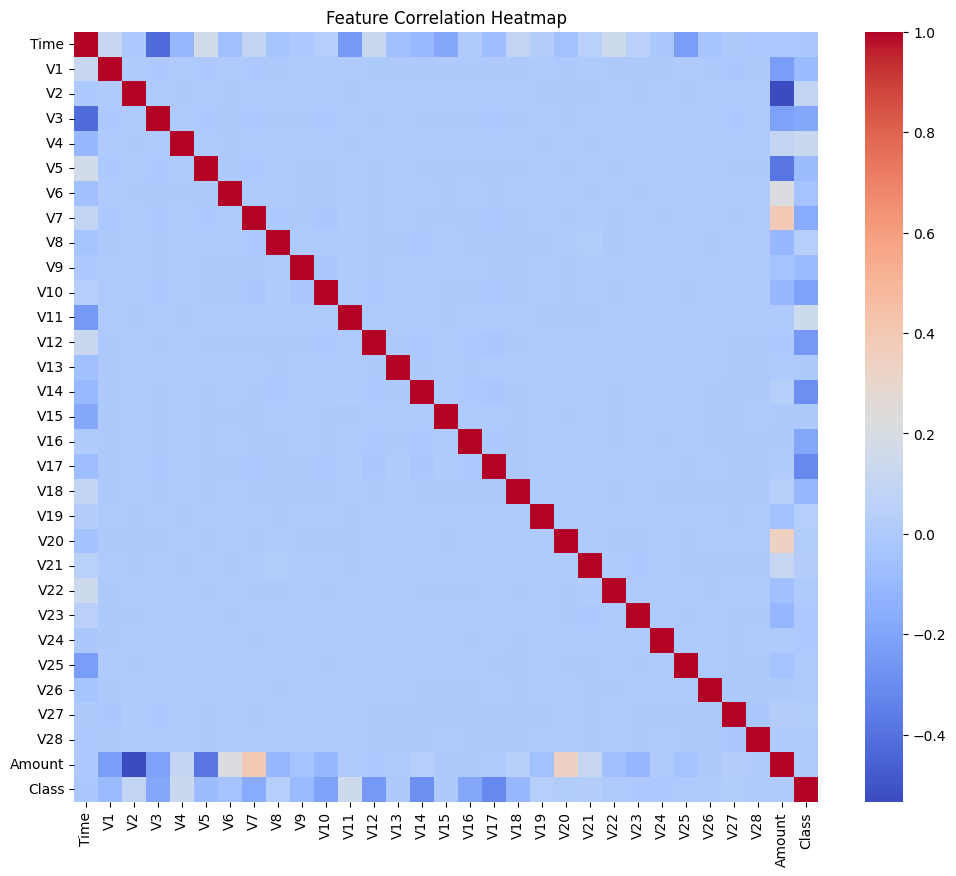

In [24]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

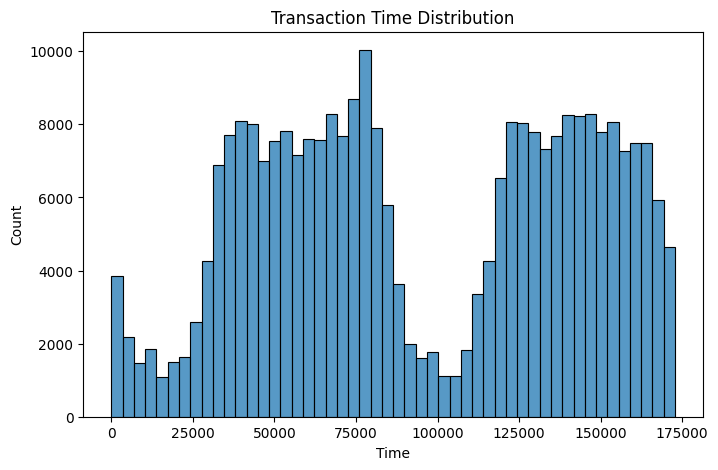

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

In [26]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [29]:
y.value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [30]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [31]:
y_resampled.value_counts()

Class
0    283253
1    283253
Name: count, dtype: int64

In [32]:
print("Original Dataset Shape:", X.shape)
print("Resampled Dataset Shape:", X_resampled.shape)

Original Dataset Shape: (283726, 30)
Resampled Dataset Shape: (566506, 30)


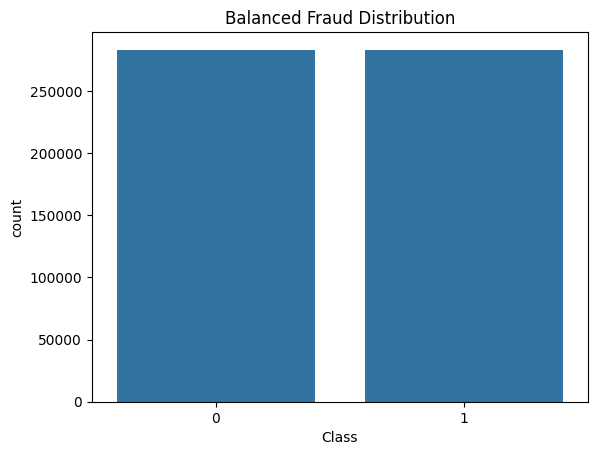

In [33]:
sns.countplot(x=y_resampled)
plt.title("Balanced Fraud Distribution")
plt.show()

In [34]:
X_resampled.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [35]:
X_resampled = X_resampled.drop("Time", axis=1)

In [36]:
X_resampled.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [37]:
X_resampled.shape

(566506, 29)

In [38]:
y_resampled.value_counts()

Class
0    283253
1    283253
Name: count, dtype: int64

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

In [41]:
X_scaled = scaler.fit_transform(X_resampled)

In [42]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X_resampled.columns)

In [43]:
X_scaled.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.179237,-0.536924,1.014115,-0.290885,0.292444,0.746899,0.548887,-0.112072,0.762142,0.682045,...,0.046223,-0.139914,0.261758,-0.075044,0.224794,0.168416,-0.491728,0.030862,-0.158928,0.238968
1,0.667737,-0.438361,0.612881,-0.589591,0.391886,0.408963,0.489011,-0.115592,0.477703,0.620625,...,-0.279538,-0.256846,-0.755557,0.151921,-0.529151,0.231049,0.222320,-0.139147,-0.070450,-0.424565
2,0.179515,-0.905486,0.884911,-0.611552,0.251284,1.577000,0.652666,-0.073499,-0.100732,0.709888,...,0.324284,0.010179,0.809916,1.018063,-1.176817,-0.571196,-0.378349,-0.194452,-0.254632,1.273308
3,0.254577,-0.569624,0.888261,-1.010812,0.374329,1.233761,0.548513,-0.039901,-0.042104,0.647317,...,-0.420775,-0.190635,-0.040785,-0.160623,-2.078150,1.009612,-0.566109,-0.053624,0.045124,0.121010
4,0.217827,-0.260508,0.846903,-0.604083,0.275250,0.519561,0.615334,-0.207673,0.970667,0.839852,...,0.205934,-0.134911,0.839441,-0.103965,0.362579,-0.373992,1.075519,0.133271,0.425219,-0.120640


In [44]:
from sklearn.ensemble import IsolationForest

In [45]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

In [46]:
iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [47]:
y_pred_iso = iso_forest.predict(X_scaled)

In [48]:
import numpy as np

y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

In [49]:
import pandas as pd

pd.Series(y_pred_iso).value_counts()

0    560840
1      5666
Name: count, dtype: int64

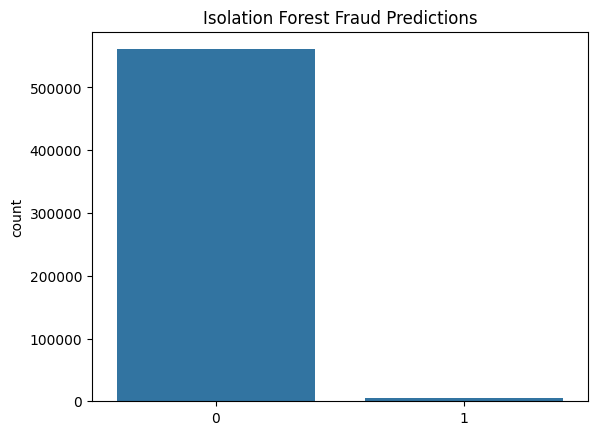

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_pred_iso)
plt.title("Isolation Forest Fraud Predictions")
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [53]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (453204, 29)
X_test shape: (113302, 29)
y_train shape: (453204,)
y_test shape: (113302,)


In [84]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [85]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [86]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

In [87]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [88]:
y_pred_xgb = xgb_model.predict(X_test)

In [89]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

In [90]:
print("Predicted classes:")
print(y_pred_xgb[:10])

print("\nPredicted probabilities:")
print(y_pred_proba[:10])

Predicted classes:
[1 1 0 0 0 1 1 0 1 0]

Predicted probabilities:
[9.9973625e-01 9.9974304e-01 7.8921032e-04 2.3697008e-04 2.1888316e-03
 9.9080288e-01 9.9979216e-01 1.3540751e-04 9.9979073e-01 2.6413810e-04]


In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [92]:
accuracy = accuracy_score(y_test, y_pred_xgb)
print("Accuracy:", accuracy)

Accuracy: 0.9989320576865368


In [93]:
precision = precision_score(y_test, y_pred_xgb)
print("Precision:", precision)

Precision: 0.9985184662598328


In [94]:
recall = recall_score(y_test, y_pred_xgb)
print("Recall:", recall)

Recall: 0.9993468782545762


In [95]:
f1 = f1_score(y_test, y_pred_xgb)
print("F1 Score:", f1)

F1 Score: 0.9989325005072828


In [96]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.999972388990902


In [97]:
cm = confusion_matrix(y_test, y_pred_xgb)
cm

array([[56567,    84],
       [   37, 56614]])

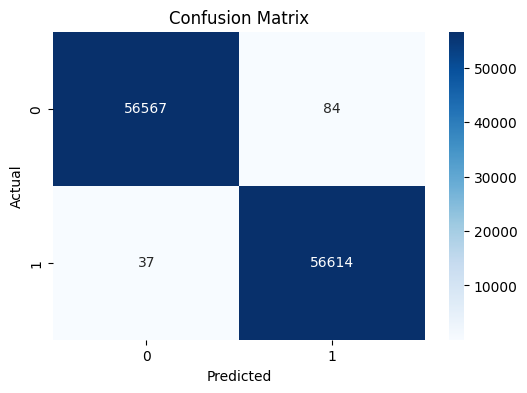

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [99]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       1.00      1.00      1.00     56651

    accuracy                           1.00    113302
   macro avg       1.00      1.00      1.00    113302
weighted avg       1.00      1.00      1.00    113302



In [100]:
from sklearn.metrics import roc_curve

In [101]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

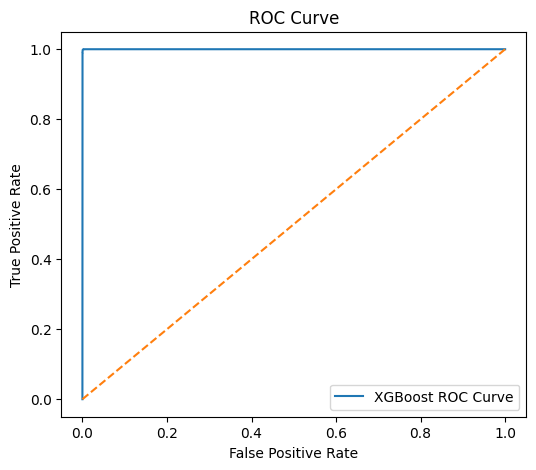

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="XGBoost ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [103]:
import pandas as pd

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_scaled.columns
)

In [104]:
top_features = feature_importance.sort_values(ascending=False).head(10)
top_features

V14       0.655305
V4        0.047830
V12       0.040058
V17       0.021780
V3        0.017585
V13       0.014803
V8        0.013906
Amount    0.012545
V1        0.012370
V23       0.011924
dtype: float32

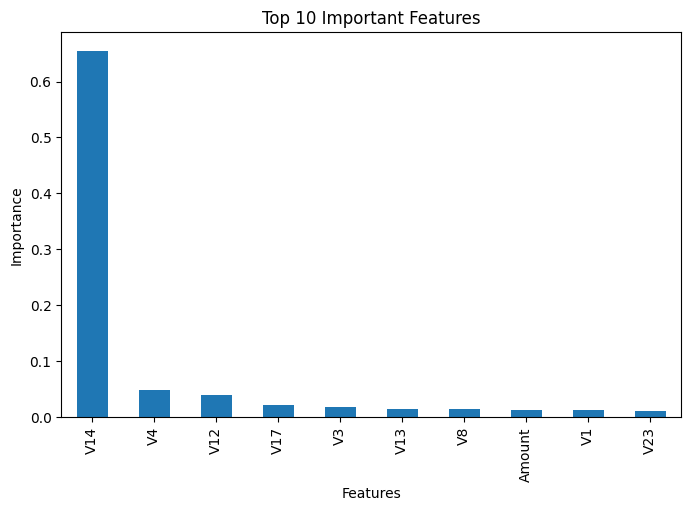

In [105]:
plt.figure(figsize=(8,5))

top_features.plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

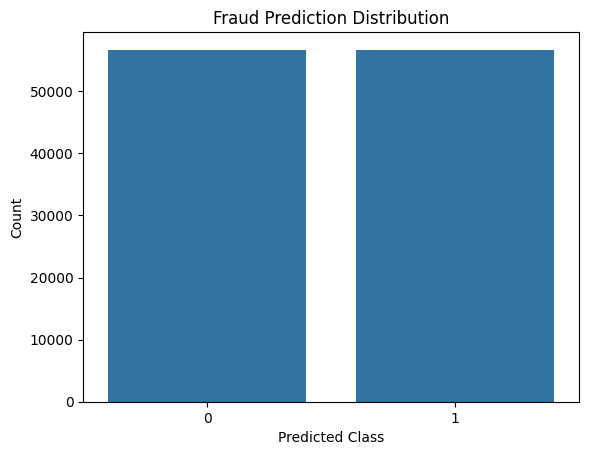

In [106]:
import seaborn as sns

sns.countplot(x=y_pred_xgb)

plt.title("Fraud Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.show()

In [107]:
def predict_fraud(transaction_data):
    transaction_df = pd.DataFrame([transaction_data], columns=X_resampled.columns)
    transaction_scaled = scaler.transform(transaction_df)
    prediction = xgb_model.predict(transaction_scaled)[0]
    probability = xgb_model.predict_proba(transaction_scaled)[0][1]

    if prediction == 1:
        result = "Fraud Transaction"
    else:
        result = "Normal Transaction"

    return result, probability

In [108]:
sample_transaction = X_resampled.iloc[0].values

In [109]:
result, probability = predict_fraud(sample_transaction)

print("Prediction:", result)
print("Fraud Probability:", probability)

Prediction: Normal Transaction
Fraud Probability: 0.010817739


In [110]:
sample_transaction_2 = X_resampled.iloc[10].values

result, probability = predict_fraud(sample_transaction_2)

print("Prediction:", result)
print("Fraud Probability:", probability)

Prediction: Normal Transaction
Fraud Probability: 0.00055368454


In [111]:
X_resampled.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')